# Offline Replay For Recorded Runtime Observations 2026-06-29

Purpose: explain why the live policy started pulling the arm toward safe pose on the recorded runs.

This notebook re-runs the policy on the exact recorded observations, then ablates state vs image:

- current image + current state
- start image + current state
- current image + start state
- start image + start state

Run on the GPU server after copying the full client-side run folders there. The server folders currently may contain only `server_actions.jsonl`; this notebook also needs `metadata.jsonl` and `images/`.

Copy from the robot/client machine if needed:

```powershell
scp recorded_obs-0629-01/client_actions.jsonl recorded_obs-0629-01/metadata.jsonl trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-01/
scp -r recorded_obs-0629-01/images trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-01/
scp recorded_obs-0629-02/client_actions.jsonl recorded_obs-0629-02/metadata.jsonl trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-02/
scp -r recorded_obs-0629-02/images trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-02/
scp recorded_obs-0629-nonrtc/client_actions.jsonl recorded_obs-0629-nonrtc/metadata.jsonl trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-nonrtc/
scp -r recorded_obs-0629-nonrtc/images trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-nonrtc/
scp recorded_obs-0629-rtc2/client_actions.jsonl recorded_obs-0629-rtc2/metadata.jsonl trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-rtc2/
scp -r recorded_obs-0629-rtc2/images trietlm@192.168.30.244:/home/trietlm/lerobot/recorded_obs-0629-rtc2/
```


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from huggingface_hub import snapshot_download

from lerobot.policies.factory import get_policy_class, make_pre_post_processors
from lerobot.rtc_inference.helpers import raw_observation_to_observation

REPO_ROOT = Path('/home/trietlm/lerobot')
RUN_DIRS = [
    REPO_ROOT / 'recorded_obs-0629-01',
    REPO_ROOT / 'recorded_obs-0629-02',
    REPO_ROOT / 'recorded_obs-0629-nonrtc',
    REPO_ROOT / 'recorded_obs-0629-rtc2',
]
SAFE_POSE_PATH = REPO_ROOT / 'safe_pose.json'

TASK = 'Pour from orange cup to blue cup.'
POLICY_TYPE = 'smolvla'
DEVICE = 'cuda'

# Main checkpoint used online.
NEW_POLICY = {'label': 'new_latest', 'repo_id': 'di-techinnova/smolvla-pouring-0.3-cutted', 'revision': None}

# Optional old checkpoint from the 50-episode-ish commit group. Enable if the model repo revision is accessible.
OLD_POLICY = {'label': 'old_50eps_revision', 'repo_id': 'di-techinnova/smolvla-pouring-0.3-cutted', 'revision': 'b6f2aafdbdd793046747fad8207459402c33c4b0'}
POLICIES_TO_RUN = [NEW_POLICY]  # Change to [NEW_POLICY, OLD_POLICY] if you want old-vs-new.

JOINT_KEYS = [
    'shoulder_pan.pos',
    'shoulder_lift.pos',
    'elbow_flex.pos',
    'wrist_flex.pos',
    'wrist_roll.pos',
    'gripper.pos',
]

RENAME_MAP = {
    'observation.images.camera1': 'observation.images.camera1',
    'observation.images.camera2': 'observation.images.camera2',
}

# saved_rgb: replay the PNGs saved by the client recorder.
# server_jpeg_bgr_q90: simulate the current online transport path when image_compress_enable=true:
#   client cv2.imencode('.jpg', RGB array) -> server cv2.imdecode(..., IMREAD_COLOR), which returns BGR.
# This catches RGB/BGR transport mismatches that the saved PNGs hide.
IMAGE_VARIANTS = ['saved_rgb', 'server_jpeg_bgr_q90']
SEEDS = list(range(20))
print('device', DEVICE, '| runs exist:', [p.exists() for p in RUN_DIRS])


/home/trietlm/lerobot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device cuda | runs exist: [True, True, True, True]


In [2]:
def load_jsonl(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]


def vec_from_state(state: dict) -> np.ndarray:
    return np.asarray([float(state[k]) for k in JOINT_KEYS], dtype=np.float64)


safe_data = json.loads(SAFE_POSE_PATH.read_text(encoding='utf-8'))['safe_pose']
SAFE_POSE = vec_from_state(safe_data)


def projection(x: np.ndarray, start: np.ndarray) -> float:
    axis = SAFE_POSE - start
    return float(np.dot(x - start, axis) / np.dot(axis, axis))


def l2(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))


def nearest_meta(metadata: list[dict], timestep: int) -> dict:
    return min(metadata, key=lambda row: abs(int(row['timestep']) - int(timestep)))


def image_path_for(run_dir: Path, camera: str, timestep: int) -> Path:
    exact = run_dir / 'images' / camera / f'{int(timestep):06d}.png'
    if exact.exists():
        return exact
    files = sorted((run_dir / 'images' / camera).glob('*.png'))
    if not files:
        raise FileNotFoundError(run_dir / 'images' / camera)
    return min(files, key=lambda p: abs(int(p.stem) - int(timestep)))


def load_rgb(path: Path) -> np.ndarray:
    # Runtime helper resizes before the policy image processor runs; bilinear resize
    # does not support uint8/Byte tensors, so keep robot-image scale but use float32.
    return np.asarray(Image.open(path).convert('RGB'), dtype=np.float32)


def load_image_for_replay(path: Path, image_variant: str) -> np.ndarray:
    rgb_u8 = np.asarray(Image.open(path).convert('RGB'), dtype=np.uint8)
    if image_variant == 'saved_rgb':
        return rgb_u8.astype(np.float32)
    if image_variant == 'server_jpeg_bgr_q90':
        import cv2

        ok, encoded = cv2.imencode('.jpg', rgb_u8, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
        if not ok:
            raise RuntimeError(f'Failed to JPEG encode {path}')
        decoded_bgr = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
        if decoded_bgr is None:
            raise RuntimeError(f'Failed to JPEG decode {path}')
        return decoded_bgr.astype(np.float32)
    raise ValueError(f'Unknown image_variant: {image_variant}')


def build_lerobot_features(run_dir: Path) -> dict:
    cam1 = load_rgb(sorted((run_dir / 'images' / 'camera1').glob('*.png'))[0])
    cam2 = load_rgb(sorted((run_dir / 'images' / 'camera2').glob('*.png'))[0])
    return {
        'observation.state': {
            'dtype': 'float32',
            'shape': (len(JOINT_KEYS),),
            'names': JOINT_KEYS,
        },
        'observation.images.camera1': {
            'dtype': 'image',
            'shape': cam1.shape,
            'names': ['height', 'width', 'channels'],
        },
        'observation.images.camera2': {
            'dtype': 'image',
            'shape': cam2.shape,
            'names': ['height', 'width', 'channels'],
        },
    }


def choose_probe_rows(run_dir: Path) -> list[dict]:
    metadata = load_jsonl(run_dir / 'metadata.jsonl')
    server = [r for r in load_jsonl(run_dir / 'server_actions.jsonl') if r.get('event') == 'chunk_generated']
    start = vec_from_state(metadata[0]['state'])
    selected = {0, len(metadata) - 1}
    for chunk in server:
        obs_ts = int(chunk['obs_timestep'])
        meta = nearest_meta(metadata, obs_ts)
        cur = vec_from_state(meta['state'])
        post = np.asarray(chunk['postprocessed_action'], dtype=np.float64)
        curr_p = projection(cur, start)
        first_p = projection(post[0], start)
        end_p = projection(post[-1], start)
        if first_p - curr_p > 0.08 or end_p - curr_p > 0.25 or curr_p > 0.75:
            idx = min(range(len(metadata)), key=lambda i: abs(int(metadata[i]['timestep']) - obs_ts))
            selected.add(idx)
    return [metadata[i] for i in sorted(selected)]


for run_dir in RUN_DIRS:
    probes = choose_probe_rows(run_dir)
    print(run_dir.name, 'probe timesteps:', [p['timestep'] for p in probes])


recorded_obs-0629-01 probe timesteps: [0, 49, 66, 119, 134, 136, 151, 153, 238, 253, 255, 257, 272, 274, 289, 291, 306, 308, 323, 325]
recorded_obs-0629-02 probe timesteps: [0, 50, 52, 84, 86, 101, 103, 118, 120, 135, 137, 152, 154, 169, 171, 186, 188, 203, 205, 220, 222]
recorded_obs-0629-nonrtc probe timesteps: [0, 17, 19, 38, 57, 74, 93, 95, 112, 114, 131, 148, 150, 167, 169, 186, 203, 205]
recorded_obs-0629-rtc2 probe timesteps: [0, 15, 17, 32, 34, 49, 66, 68, 83, 85, 100, 102, 117, 119, 134, 136, 151]


In [3]:
def load_policy(spec: dict):
    repo_id = spec['repo_id']
    revision = spec.get('revision')
    local_path = snapshot_download(repo_id=repo_id, revision=revision) if revision else repo_id
    policy_class = get_policy_class(POLICY_TYPE)
    policy = policy_class.from_pretrained(local_path)
    policy.to(DEVICE).eval()
    device_override = {'device': DEVICE}
    preprocessor, postprocessor = make_pre_post_processors(
        policy.config,
        pretrained_path=local_path,
        preprocessor_overrides={
            'device_processor': device_override,
            'rename_observations_processor': {'rename_map': RENAME_MAP},
        },
        postprocessor_overrides={'device_processor': device_override},
    )
    return policy, preprocessor, postprocessor


POLICY_CACHE = {}
for spec in POLICIES_TO_RUN:
    print('loading', spec)
    POLICY_CACHE[spec['label']] = load_policy(spec)
print('loaded:', list(POLICY_CACHE))


loading {'label': 'new_latest', 'repo_id': 'di-techinnova/smolvla-pouring-0.3-cutted', 'revision': None}
Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
Loading weights: 100%|██████████| 489/489 [00:00<00:00, 4643.13it/s]


Reducing the number of VLM layers to 16 ...
loaded: ['new_latest']


In [4]:
def make_raw_obs(run_dir: Path, image_row: dict, state_row: dict, image_variant: str) -> dict:
    raw = {k: float(state_row['state'][k]) for k in JOINT_KEYS}
    image_ts = int(image_row['timestep'])
    raw['camera1'] = load_image_for_replay(image_path_for(run_dir, 'camera1', image_ts), image_variant)
    raw['camera2'] = load_image_for_replay(image_path_for(run_dir, 'camera2', image_ts), image_variant)
    raw['task'] = TASK
    return raw


def predict_chunk(policy_bundle, run_dir: Path, image_row: dict, state_row: dict, seed: int, image_variant: str) -> np.ndarray:
    policy, preprocessor, postprocessor = policy_bundle
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    raw_obs = make_raw_obs(run_dir, image_row, state_row, image_variant)
    lerobot_features = build_lerobot_features(run_dir)
    # Match the live policy_server path exactly: resize image, scale to [0, 1],
    # add image batch dim, then run the policy preprocessor.
    obs = raw_observation_to_observation(
        raw_obs,
        lerobot_features,
        policy.config.image_features,
        rename_map=RENAME_MAP,
    )
    obs = preprocessor(obs)
    with torch.inference_mode():
        raw_action = policy.predict_action_chunk(obs)
    if raw_action.ndim != 3:
        raw_action = raw_action.unsqueeze(0)
    _, chunk_size, _ = raw_action.shape
    processed = []
    for i in range(chunk_size):
        processed.append(postprocessor(raw_action[:, i, :]))
    return torch.stack(processed, dim=1).squeeze(0).detach().cpu().numpy()


def summarize_chunk(chunk: np.ndarray, current: np.ndarray, start: np.ndarray) -> dict:
    ps = np.asarray([projection(a, start) for a in chunk])
    steps = np.linalg.norm(np.diff(chunk, axis=0), axis=1) if len(chunk) > 1 else np.asarray([])
    return {
        'p_first': float(ps[0]),
        'p_end': float(ps[-1]),
        'p_max': float(ps.max()),
        'p_mean': float(ps.mean()),
        'first_dist_current': l2(chunk[0], current),
        'end_dist_current': l2(chunk[-1], current),
        'first_dist_safe': l2(chunk[0], SAFE_POSE),
        'end_dist_safe': l2(chunk[-1], SAFE_POSE),
        'chunk_step_mean': float(steps.mean()) if len(steps) else np.nan,
    }


ABLATIONS = [
    ('current_image_current_state', 'current', 'current'),
    ('start_image_current_state', 'start', 'current'),
    ('current_image_start_state', 'current', 'start'),
    ('start_image_start_state', 'start', 'start'),
]


In [5]:
records = []

for run_dir in RUN_DIRS:
    metadata = load_jsonl(run_dir / 'metadata.jsonl')
    start_row = metadata[0]
    start_state = vec_from_state(start_row['state'])
    probe_rows = choose_probe_rows(run_dir)
    for policy_label, bundle in POLICY_CACHE.items():
        for current_row in probe_rows:
            current_state = vec_from_state(current_row['state'])
            current_p = projection(current_state, start_state)
            for image_variant in IMAGE_VARIANTS:
                for ablation_label, image_mode, state_mode in ABLATIONS:
                    image_row = current_row if image_mode == 'current' else start_row
                    state_row = current_row if state_mode == 'current' else start_row
                    for seed in SEEDS:
                        try:
                            chunk = predict_chunk(bundle, run_dir, image_row, state_row, seed, image_variant)
                        except Exception as exc:
                            records.append({
                                'run': run_dir.name,
                                'policy': policy_label,
                                'obs_timestep': current_row['timestep'],
                                'image_variant': image_variant,
                                'ablation': ablation_label,
                                'seed': seed,
                                'error': repr(exc),
                            })
                            continue
                        rec = {
                            'run': run_dir.name,
                            'policy': policy_label,
                            'obs_timestep': current_row['timestep'],
                            'elapsed_s': current_row['elapsed_s'],
                            'current_p': current_p,
                            'image_variant': image_variant,
                            'ablation': ablation_label,
                            'seed': seed,
                            'error': None,
                        }
                        rec.update(summarize_chunk(chunk, current_state, start_state))
                        records.append(rec)

df = pd.DataFrame(records)
out_dir = REPO_ROOT / 'xai' / 'offline_replay_recorded_obs_0629_outputs'
out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / 'ablation_predictions.csv', index=False)
error_count = int(df['error'].notna().sum()) if 'error' in df else 0
print('rows', len(df), 'errors', error_count)
if error_count:
    error_summary = df.loc[df['error'].notna(), 'error'].value_counts().head(10)
    display(error_summary.rename('count').to_frame())
df.head()


rows 12160 errors 0


,run,policy,obs_timestep,elapsed_s,current_p,image_variant,ablation,seed,error,p_first,p_end,p_max,p_mean,first_dist_current,end_dist_current,first_dist_safe,end_dist_safe,chunk_step_mean
0,recorded_obs-0629-01,new_latest,0,0.0,0.0,saved_rgb,current_image_current_state,0,None,-0.005414,0.040729,0.097053,0.039810,5.112416,11.866770,145.443006,139.066299,3.053420
1,recorded_obs-0629-01,new_latest,0,0.0,0.0,saved_rgb,current_image_current_state,1,None,-0.019540,0.086420,0.283235,0.118130,4.284778,21.425457,147.432544,133.220489,4.535609
2,recorded_obs-0629-01,new_latest,0,0.0,0.0,saved_rgb,current_image_current_state,2,None,0.006699,0.065745,0.269270,0.107451,4.027890,14.448401,143.657189,135.505101,4.350760
3,recorded_obs-0629-01,new_latest,0,0.0,0.0,saved_rgb,current_image_current_state,3,None,0.012148,0.016074,0.090742,0.009798,5.704075,10.974236,142.919237,142.652377,3.066726
4,recorded_obs-0629-01,new_latest,0,0.0,0.0,saved_rgb,current_image_current_state,4,None,-0.000948,0.034502,0.215741,0.061878,4.291530,9.748829,144.773022,139.835528,3.617582


In [6]:
ok = df[df['error'].isna()].copy()
if ok.empty:
    error_summary = df.loc[df['error'].notna(), 'error'].value_counts().head(20)
    display(error_summary.rename('count').to_frame())
    raise RuntimeError('No successful policy replay rows. Fix the errors above before summarizing.')

required_columns = {'current_p', 'p_first', 'p_end', 'p_max', 'first_dist_current', 'chunk_step_mean'}
missing_columns = sorted(required_columns - set(ok.columns))
if missing_columns:
    raise RuntimeError(f'Successful replay rows are missing expected columns: {missing_columns}')

summary = (
    ok.groupby(['run', 'policy', 'obs_timestep', 'current_p', 'image_variant', 'ablation'])
    .agg(
        p_first_mean=('p_first', 'mean'),
        p_first_std=('p_first', 'std'),
        p_end_mean=('p_end', 'mean'),
        p_end_std=('p_end', 'std'),
        p_max_mean=('p_max', 'mean'),
        first_dist_current_mean=('first_dist_current', 'mean'),
        chunk_step_mean=('chunk_step_mean', 'mean'),
        n=('seed', 'count'),
    )
    .reset_index()
)
summary['end_minus_current_p'] = summary['p_end_mean'] - summary['current_p']
summary['first_minus_current_p'] = summary['p_first_mean'] - summary['current_p']
summary.to_csv(out_dir / 'ablation_summary.csv', index=False)
summary.sort_values(['run', 'obs_timestep', 'ablation']).head(40)


,run,policy,obs_timestep,current_p,image_variant,ablation,p_first_mean,p_first_std,p_end_mean,p_end_std,p_max_mean,first_dist_current_mean,chunk_step_mean,n,end_minus_current_p,first_minus_current_p
0,recorded_obs-0629-01,new_latest,0,0.000000,saved_rgb,current_image_current_state,0.000271,0.015090,0.041757,0.025818,0.159854,4.825848,3.445404,20,0.041757,0.000271
4,recorded_obs-0629-01,new_latest,0,0.000000,server_jpeg_bgr_q90,current_image_current_state,-0.001605,0.014336,0.022903,0.022438,0.110682,4.939158,2.955266,20,0.022903,-0.001605
1,recorded_obs-0629-01,new_latest,0,0.000000,saved_rgb,current_image_start_state,0.000271,0.015090,0.041757,0.025818,0.159854,4.825848,3.445404,20,0.041757,0.000271
5,recorded_obs-0629-01,new_latest,0,0.000000,server_jpeg_bgr_q90,current_image_start_state,-0.001605,0.014336,0.022903,0.022438,0.110682,4.939158,2.955266,20,0.022903,-0.001605
2,recorded_obs-0629-01,new_latest,0,0.000000,saved_rgb,start_image_current_state,0.000271,0.015090,0.041757,0.025818,0.159854,4.825848,3.445404,20,0.041757,0.000271
6,recorded_obs-0629-01,new_latest,0,0.000000,server_jpeg_bgr_q90,start_image_current_state,-0.001605,0.014336,0.022903,0.022438,0.110682,4.939158,2.955266,20,0.022903,-0.001605
3,recorded_obs-0629-01,new_latest,0,0.000000,saved_rgb,start_image_start_state,0.000271,0.015090,0.041757,0.025818,0.159854,4.825848,3.445404,20,0.041757,0.000271
7,recorded_obs-0629-01,new_latest,0,0.000000,server_jpeg_bgr_q90,start_image_start_state,-0.001605,0.014336,0.022903,0.022438,0.110682,4.939158,2.955266,20,0.022903,-0.001605
8,recorded_obs-0629-01,new_latest,49,0.095608,saved_rgb,current_image_current_state,0.083800,0.022267,0.370017,0.226109,0.420235,6.234192,4.865581,20,0.274409,-0.011808
12,recorded_obs-0629-01,new_latest,49,0.095608,server_jpeg_bgr_q90,current_image_current_state,0.082916,0.022262,0.282843,0.191286,0.336992,6.451205,4.504377,20,0.187235,-0.012692


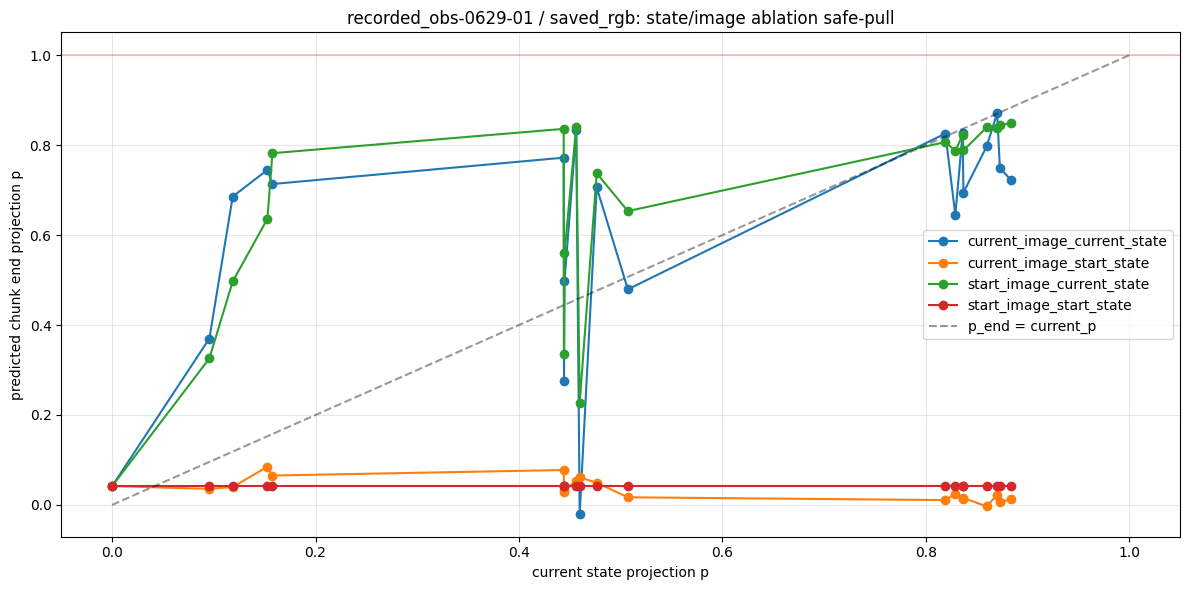

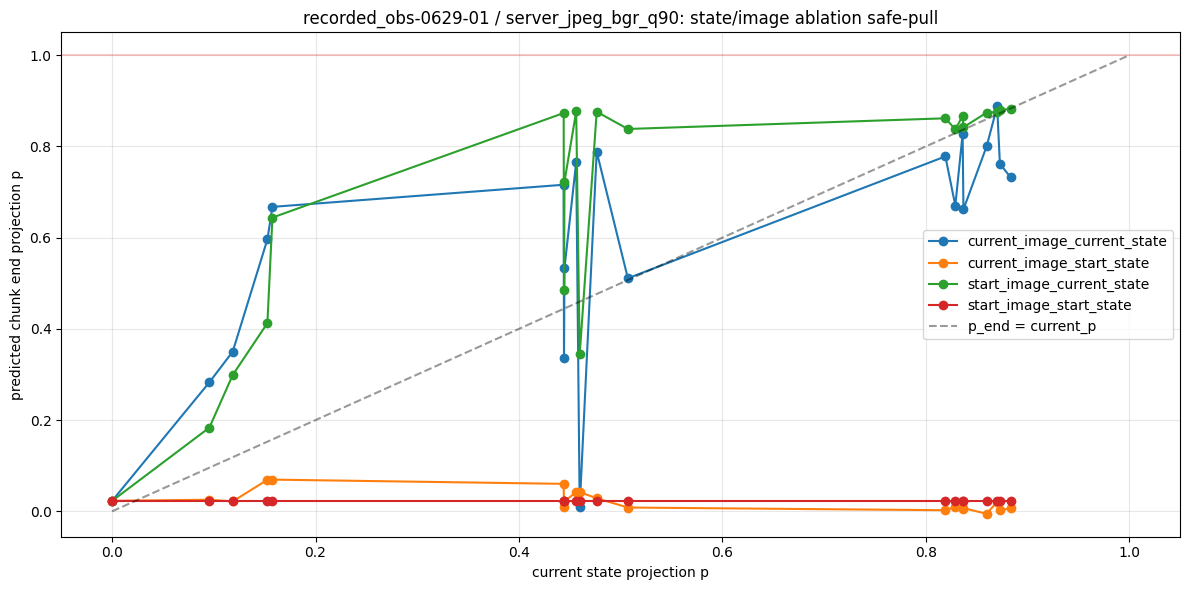

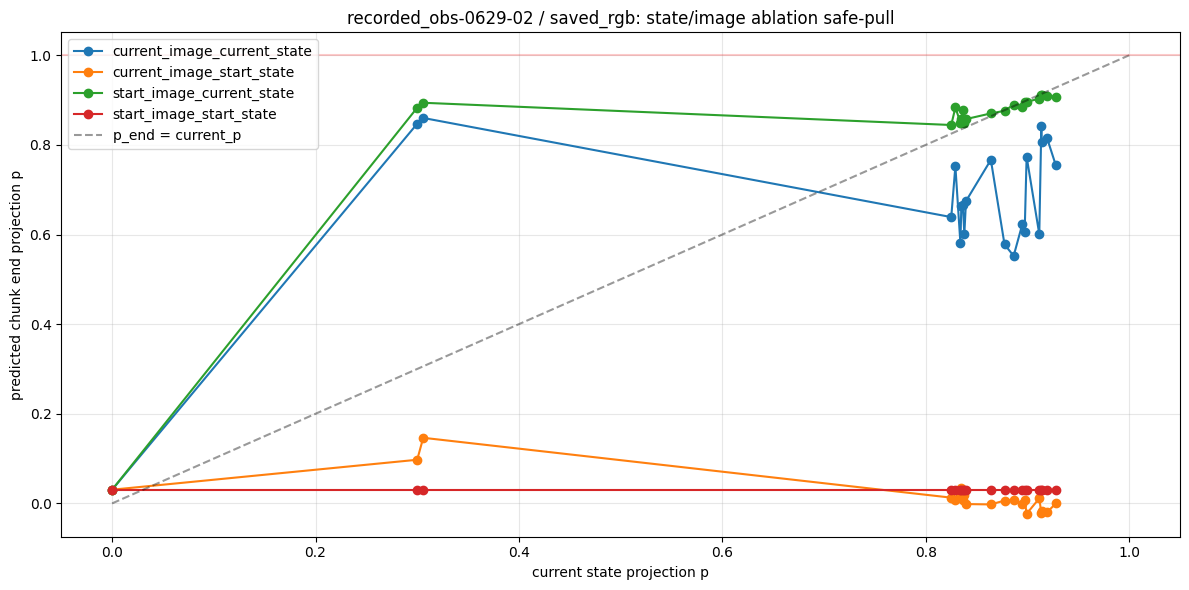

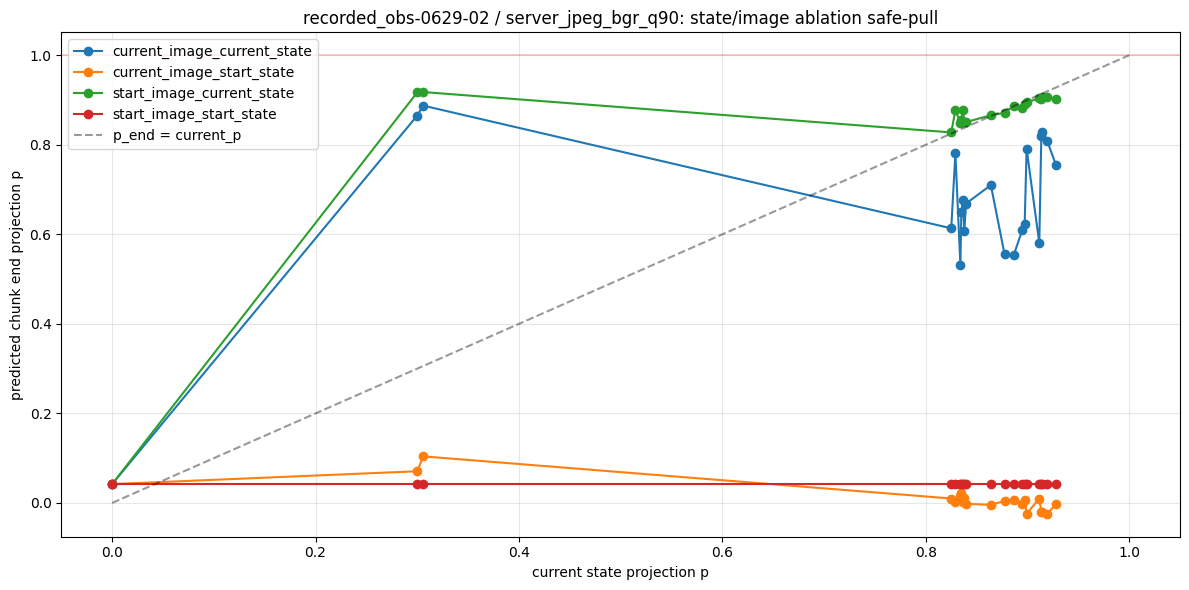

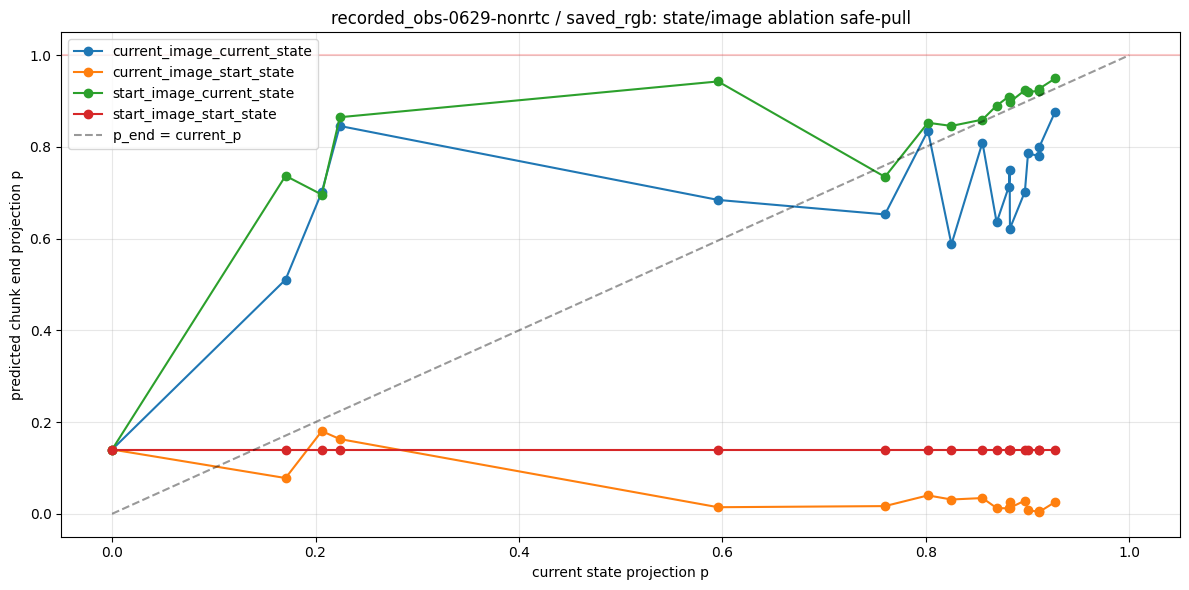

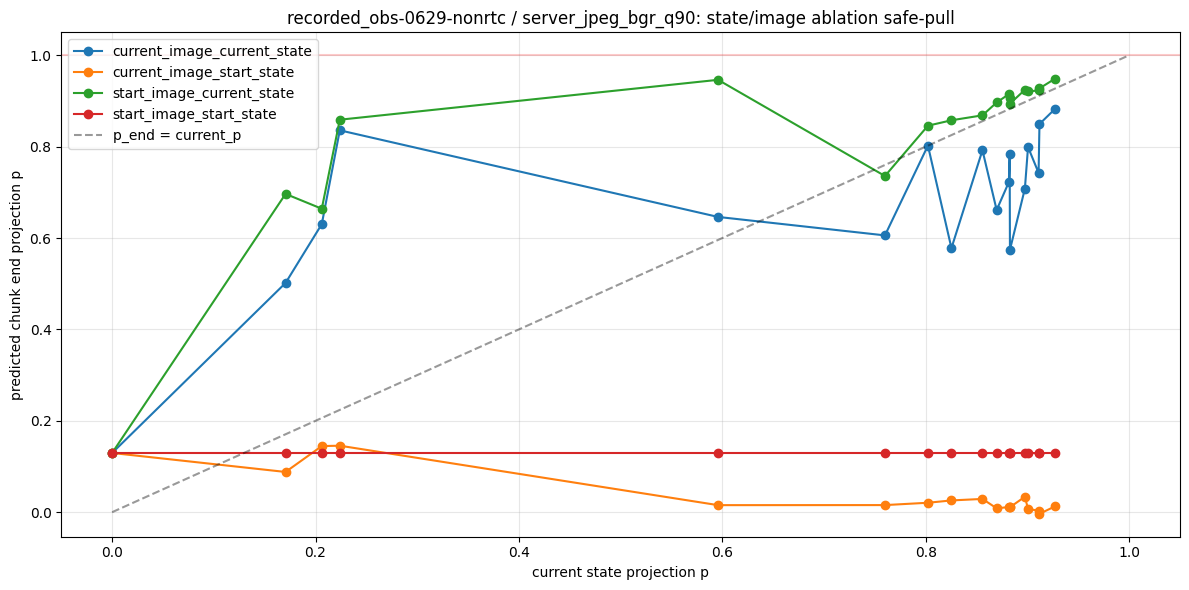

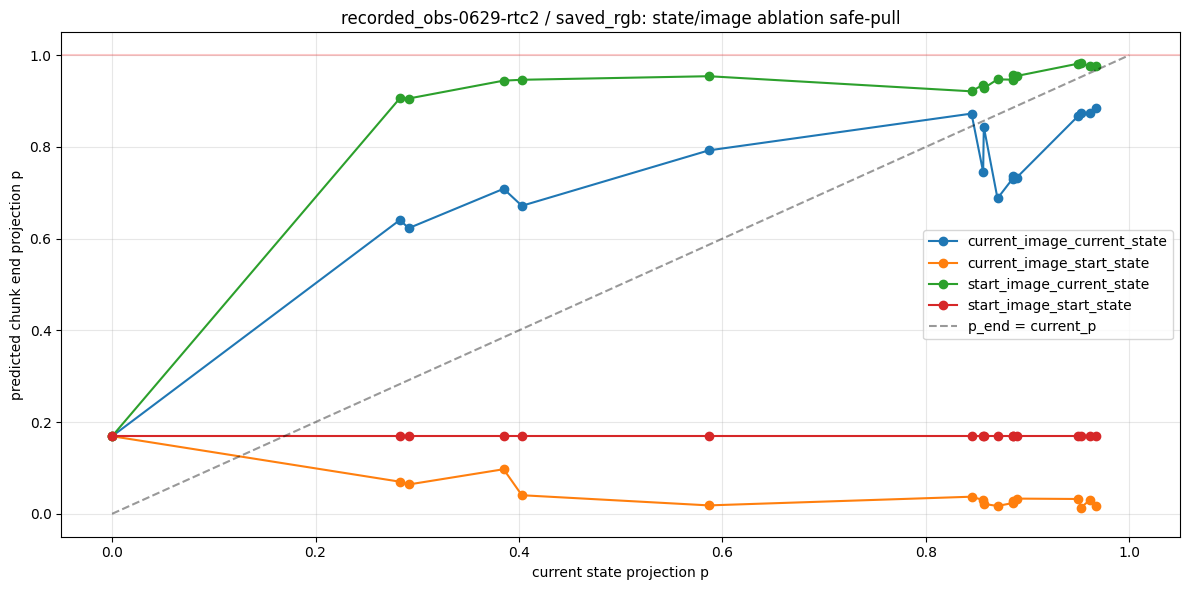

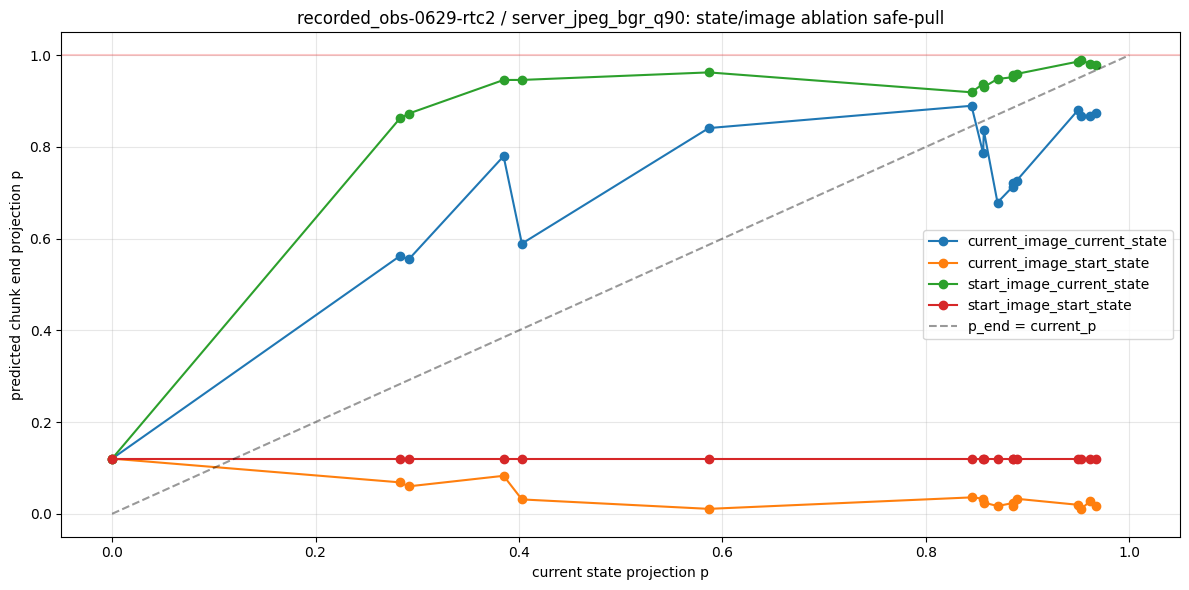

wrote outputs to /home/trietlm/lerobot/xai/offline_replay_recorded_obs_0629_outputs


In [7]:
for run in summary['run'].unique():
    for image_variant in summary['image_variant'].unique():
        sub = summary[
            (summary['run'] == run)
            & (summary['policy'] == POLICIES_TO_RUN[0]['label'])
            & (summary['image_variant'] == image_variant)
        ]
        if sub.empty:
            continue
        plt.figure(figsize=(12, 6))
        for ablation in sub['ablation'].unique():
            s = sub[sub['ablation'] == ablation].sort_values('current_p')
            plt.plot(s['current_p'], s['p_end_mean'], marker='o', label=ablation)
        xs = np.linspace(0, 1, 100)
        plt.plot(xs, xs, '--', color='black', alpha=0.4, label='p_end = current_p')
        plt.axhline(1.0, color='red', alpha=0.2)
        plt.xlabel('current state projection p')
        plt.ylabel('predicted chunk end projection p')
        plt.title(f'{run} / {image_variant}: state/image ablation safe-pull')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_dir / f'{run}_{image_variant}_ablation_p_end.png', dpi=160)
        plt.show()

print('wrote outputs to', out_dir)


## Server JSONL Match Check

This cell compares offline replay against `server_actions.jsonl` at the same `obs_timestep`. For non-RTC runs, a correct replay path should be close to server `postprocessed_action`. For RTC runs, exact match is not expected because live server may condition on `prev_chunk_left_over`, but the comparison still shows directionality.


In [8]:
server_compare_records = []

for run_dir in RUN_DIRS:
    server_path = run_dir / 'server_actions.jsonl'
    meta_path = run_dir / 'metadata.jsonl'
    if not server_path.exists() or not meta_path.exists():
        print('skip missing server/meta:', run_dir)
        continue

    metadata = load_jsonl(meta_path)
    start_state = vec_from_state(metadata[0]['state'])
    server_chunks = [r for r in load_jsonl(server_path) if r.get('event') == 'chunk_generated']
    offline = summary[
        (summary['run'] == run_dir.name)
        & (summary['policy'] == POLICIES_TO_RUN[0]['label'])
        & (summary['ablation'] == 'current_image_current_state')
    ]

    for chunk in server_chunks:
        obs_ts = int(chunk['obs_timestep'])
        meta = nearest_meta(metadata, obs_ts)
        cur = vec_from_state(meta['state'])
        post = np.asarray(chunk['postprocessed_action'], dtype=np.float64)
        server_first_p = projection(post[0], start_state)
        server_end_p = projection(post[-1], start_state)
        server_max_p = max(projection(a, start_state) for a in post)
        current_p = projection(cur, start_state)

        matches = offline[offline['obs_timestep'] == obs_ts]
        if matches.empty:
            server_compare_records.append({
                'run': run_dir.name,
                'obs_timestep': obs_ts,
                'server_rtc_enabled': chunk.get('rtc_enabled'),
                'server_rtc_real_delay': chunk.get('rtc_real_delay'),
                'current_p': current_p,
                'server_first_p': server_first_p,
                'server_end_p': server_end_p,
                'server_max_p': server_max_p,
                'image_variant': '<not_replayed>',
                'offline_first_mean': np.nan,
                'offline_end_mean': np.nan,
                'offline_max_mean': np.nan,
                'delta_end_server_minus_offline': np.nan,
            })
            continue

        for _, row in matches.iterrows():
            server_compare_records.append({
                'run': run_dir.name,
                'obs_timestep': obs_ts,
                'server_rtc_enabled': chunk.get('rtc_enabled'),
                'server_rtc_real_delay': chunk.get('rtc_real_delay'),
                'current_p': current_p,
                'server_first_p': server_first_p,
                'server_end_p': server_end_p,
                'server_max_p': server_max_p,
                'image_variant': row['image_variant'],
                'offline_first_mean': row['p_first_mean'],
                'offline_end_mean': row['p_end_mean'],
                'offline_max_mean': row['p_max_mean'],
                'delta_end_server_minus_offline': server_end_p - row['p_end_mean'],
                'delta_first_server_minus_offline': server_first_p - row['p_first_mean'],
                'offline_end_minus_current_p': row['end_minus_current_p'],
                'server_end_minus_current_p': server_end_p - current_p,
            })

server_compare = pd.DataFrame(server_compare_records)
server_compare.to_csv(out_dir / 'server_replay_compare.csv', index=False)
print('server compare rows', len(server_compare))
if not server_compare.empty:
    display(
        server_compare
        .groupby(['run', 'server_rtc_enabled', 'image_variant'], dropna=False)
        .agg(
            n=('obs_timestep', 'count'),
            abs_delta_end_mean=('delta_end_server_minus_offline', lambda x: float(np.nanmean(np.abs(x)))),
            delta_end_mean=('delta_end_server_minus_offline', 'mean'),
            server_safe_pull_count=('server_end_minus_current_p', lambda x: int((x > 0.05).sum())),
            offline_safe_pull_count=('offline_end_minus_current_p', lambda x: int((x > 0.05).sum())),
        )
        .reset_index()
    )
    display(
        server_compare
        .sort_values('delta_end_server_minus_offline', key=lambda s: s.abs(), ascending=False)
        .head(40)
    )


server compare rows 184


/tmp/ipykernel_2945912/1027207342.py:77: RuntimeWarning: Mean of empty slice
  abs_delta_end_mean=('delta_end_server_minus_offline', lambda x: float(np.nanmean(np.abs(x)))),


,run,server_rtc_enabled,image_variant,n,abs_delta_end_mean,delta_end_mean,server_safe_pull_count,offline_safe_pull_count
0,recorded_obs-0629-01,True,<not_replayed>,20,NaN,NaN,0,0
1,recorded_obs-0629-01,True,saved_rgb,20,0.128318,0.046485,10,8
2,recorded_obs-0629-01,True,server_jpeg_bgr_q90,20,0.160611,0.073149,10,8
3,recorded_obs-0629-02,True,<not_replayed>,6,NaN,NaN,0,0
4,recorded_obs-0629-02,True,saved_rgb,21,0.094756,0.006650,3,2
5,recorded_obs-0629-02,True,server_jpeg_bgr_q90,21,0.089402,0.010141,3,2
6,recorded_obs-0629-nonrtc,False,<not_replayed>,3,NaN,NaN,0,0
7,recorded_obs-0629-nonrtc,False,saved_rgb,18,0.080438,0.058779,7,5
8,recorded_obs-0629-nonrtc,False,server_jpeg_bgr_q90,18,0.088491,0.069282,7,5
9,recorded_obs-0629-rtc2,True,<not_replayed>,1,NaN,NaN,0,0


,run,obs_timestep,server_rtc_enabled,server_rtc_real_delay,current_p,server_first_p,server_end_p,server_max_p,image_variant,offline_first_mean,offline_end_mean,offline_max_mean,delta_end_server_minus_offline,delta_first_server_minus_offline,offline_end_minus_current_p,server_end_minus_current_p
19,recorded_obs-0629-01,134,True,3.0,0.444309,0.569345,0.934065,0.947054,saved_rgb,0.442315,0.275713,0.623662,0.658352,0.127030,-0.168596,0.489757
20,recorded_obs-0629-01,134,True,3.0,0.444309,0.569345,0.934065,0.947054,server_jpeg_bgr_q90,0.443709,0.336109,0.681144,0.597956,0.125636,-0.108199,0.489757
10,recorded_obs-0629-01,66,True,3.0,0.118581,0.094037,0.809836,0.809836,server_jpeg_bgr_q90,0.104220,0.350266,0.401296,0.459570,-0.010183,0.231685,0.691255
42,recorded_obs-0629-01,257,True,3.0,0.507115,0.651722,0.850727,0.928021,saved_rgb,0.504861,0.479435,0.791080,0.371291,0.146861,-0.027679,0.343612
43,recorded_obs-0629-01,257,True,3.0,0.507115,0.651722,0.850727,0.928021,server_jpeg_bgr_q90,0.508804,0.510923,0.832377,0.339804,0.142918,0.003808,0.343612
82,recorded_obs-0629-02,120,True,3.0,0.864026,0.880939,0.448821,0.942123,saved_rgb,0.871464,0.766573,0.946956,-0.317753,0.009475,-0.097453,-0.415206
156,recorded_obs-0629-rtc2,32,True,3.0,0.402900,0.452301,0.865716,0.889122,server_jpeg_bgr_q90,0.387070,0.589215,0.764892,0.276501,0.065232,0.186316,0.462816
152,recorded_obs-0629-rtc2,15,True,3.0,0.291576,0.290463,0.829314,0.829314,server_jpeg_bgr_q90,0.260169,0.554694,0.590114,0.274620,0.030294,0.263118,0.537738
55,recorded_obs-0629-01,308,True,3.0,0.836259,0.816608,0.555382,0.926783,server_jpeg_bgr_q90,0.847997,0.827675,0.963111,-0.272293,-0.031389,-0.008584,-0.280877
54,recorded_obs-0629-01,308,True,3.0,0.836259,0.816608,0.555382,0.926783,saved_rgb,0.844767,0.826735,0.945421,-0.271353,-0.028159,-0.009525,-0.280877


## How to interpret

Use `ablation_summary.csv` and the plots:

- If `current_image_current_state` pulls safe and `start_image_current_state` also pulls safe, state is likely enough to trigger safe mode.
- If only `current_image_current_state` pulls safe but `start_image_current_state` does not, runtime image/camera view is likely the trigger.
- If `current_image_start_state` pulls safe, image alone can trigger safe mode.
- If seed variance is large (`p_end_std` high), stochastic multimode remains a live suspect.
- If old policy does not pull safe on the same ablations while new does, the problem is model/checkpoint/data distribution, not runtime code.
